# Notebook Finance AI - Asistente Inteligente de Salud Financiera

## Librerias necesarias

In [264]:
import pandas as pd
import numpy as np
# import seaborn as sns
import matplotlib.pyplot as plt
# import requests
# import json
import numpy as np
import pandas as pd

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split, StratifiedKFold,cross_validate
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from imblearn.pipeline import Pipeline as imbpipeline
from imblearn.over_sampling import SMOTE

Obtención de datos 

In [265]:
# url = 'https://raw.githubusercontent.com/No-Country-simulation/G9-LATAM-Team71/refs/heads/develop/data-science/csv_prueba_modelo.csv' 
url = 'csv_prueba_modelo.csv'
data = pd.read_csv(url)

data = data.drop(index=761)
data.info()

<class 'pandas.DataFrame'>
Index: 1133 entries, 0 to 1133
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   descripcion  1133 non-null   str  
 1   categoria    1133 non-null   str  
 2   tipo         1133 non-null   str  
 3   cualidad     1133 non-null   str  
 4   monto        1133 non-null   str  
 5   fecha        1133 non-null   str  
dtypes: str(6)
memory usage: 62.0 KB


Separacion de variables, la variable a predecir (y) es la categoria que representa la descripción

In [266]:
y_categoria = data.categoria
X_categoria = X_cualidad = data.descripcion
y_cualidad = data.cualidad

Grupo de palabras que se usan para delimitar la oración, y quedan fuera de nuestra lista

In [267]:
stop_words = [
    "de",
    "del",
    "la",
    "las",
    "el",
    "los",
    "en",
    "con",
    "para",
    "por",
    "y"
]

In [268]:
# funcion para dividir datos
def split_variables(X,y):
    X,X_test,y,y_test = train_test_split(X,y,stratify = y,random_state=5,test_size=0.15)#stratify indica que si hay un 10% de una variable, entonces ese 10 % tambien lo ponga en la division
    X_train,X_val,y_train,y_val = train_test_split(X,y,stratify = y,random_state=5) #x de entrenamiento
    return X,X_test,X_train, X_val,y,y_test, y_train, y_val

X_categoria, X_categoria_test,X_categoria_train, X_categoria_val, y_categoria, y_categoria_test, y_categoria_train,y_categoria_val = split_variables(X_categoria,y_categoria) # datos de entrenamiento para categoria

X_cualidad, X_cualidad_test,X_cualidad_train, X_cualidad_val, y_cualidad, y_cualidad_test, y_cualidad_train, y_cualidad_val = split_variables(X_cualidad,y_cualidad)   #datos de entrenamiento para cualidad

vectorizer = TfidfVectorizer(stop_words=stop_words)

skf = StratifiedKFold(n_splits = 5,shuffle = True,random_state = 5)

In [269]:
y_categoria.value_counts()

categoria
alimentacion    380
transporte      109
servicios       106
ocio            103
salud            74
educacion        69
vivienda         53
deudas           45
ingreso          24
Name: count, dtype: int64

In [270]:
# funcion prueba modelo
# metricas
metrics = ['accuracy','recall_macro','f1_macro']


def probar_modelo(X,y, modelo, balanceo = None):
  pipeline = imbpipeline([('vectorizacion',vectorizer),('balanceo',balanceo),('modelo',modelo)])

  cv_resultados = cross_validate(pipeline,X,y,cv=skf,scoring=metrics)
  return cv_resultados


# funcion ejecutar modelo
def entrenar_modelo(modelo, balanceo = None):
  pipeline = imbpipeline([('vectorizacion',vectorizer),('balanceo',balanceo),('modelo',modelo)])

  return pipeline

## Modelos a probar

* Logistic Regression
* Random Forest
* Linear SVC

### Logistic Regression

Es un modelo parecido a *Linear Regression* con la diferencia de que este modelo predice a partir de categorías y no de números como lo hace la regresión lineal

In [271]:
regresion = LogisticRegression()
#categoria
mod_categoria_regresion_normal = probar_modelo(X_categoria,y_categoria,regresion);
mod_categoria_regresion_balanceado = probar_modelo(X_categoria,y_categoria,regresion,SMOTE());

#cualidad
mod_cualidad_regresion_normal = probar_modelo(X_cualidad,y_cualidad,regresion);
mod_cualidad_regresion_balanceado = probar_modelo(X_cualidad,y_cualidad,regresion,SMOTE());

pd.DataFrame({
    "Regresion lineal categoria":pd.DataFrame(mod_categoria_regresion_normal).mean(),
    "Regresion lineal categoria balanceada":pd.DataFrame(mod_categoria_regresion_balanceado).mean(),
    "Regresion lineal cualidad":pd.DataFrame(mod_categoria_regresion_normal).mean(),
    "Regresion lineal cualidad balanceada":pd.DataFrame(mod_categoria_regresion_balanceado).mean()
}).T

,fit_time,score_time,test_accuracy,test_recall_macro,test_f1_macro
Regresion lineal categoria,0.052010,0.010879,0.707168,0.535944,0.607156
Regresion lineal categoria balanceada,0.087304,0.007801,0.820396,0.774195,0.791183
Regresion lineal cualidad,0.052010,0.010879,0.707168,0.535944,0.607156
Regresion lineal cualidad balanceada,0.087304,0.007801,0.820396,0.774195,0.791183


### Random Forest

In [272]:
forest = RandomForestClassifier(max_depth=5)

mod_categoria_forest = probar_modelo(X_categoria,y_categoria,forest);
mod_categoria_forest_balanceado = probar_modelo(X_categoria,y_categoria,forest,SMOTE());

#cualidad
mod_cualidad_forest_normal = probar_modelo(X_cualidad,y_cualidad,forest);
mod_cualidad_forest_balanceado = probar_modelo(X_cualidad,y_cualidad,forest,SMOTE());

# forest_normal = probar_modelo(forest)
# forest_smote = probar_modelo(forest,SMOTE())

pd.DataFrame({
    "Modelo Forest categoria":pd.DataFrame(mod_categoria_forest).mean(),
    "Modelo Forest categoria balanceado":pd.DataFrame(mod_categoria_forest_balanceado).mean(),
    "Modelo Forest cualidad":pd.DataFrame(mod_cualidad_forest_normal).mean(),
    "Modelo Forest cualidad balanceado":pd.DataFrame(mod_cualidad_forest_balanceado).mean()
}).T

,fit_time,score_time,test_accuracy,test_recall_macro,test_f1_macro
Modelo Forest categoria,0.122239,0.015347,0.445493,0.193923,0.196761
Modelo Forest categoria balanceado,0.162273,0.014808,0.660465,0.525156,0.560272
Modelo Forest cualidad,0.115583,0.013473,0.804782,0.364414,0.352613
Modelo Forest cualidad balanceado,0.134608,0.013780,0.873327,0.732690,0.753575


### Linear SVC

In [273]:
from sklearn.svm import LinearSVC

svm = LinearSVC()
mod_categoria_LinearSVC_normal = probar_modelo(X_categoria,y_categoria,svm);
mod_categoria_LinearSVC_balanceado = probar_modelo(X_categoria,y_categoria,svm,SMOTE());

#cualidad
mod_cualidad_LinearSVC_normal = probar_modelo(X_cualidad,y_cualidad,regresion);
mod_cualidad_LinearSVC_balanceado = probar_modelo(X_cualidad,y_cualidad,svm,SMOTE());

# modelo_svm_normal = probar_modelo(svm)
# modelo_svm_balanceado = probar_modelo(svm, SMOTE())
pd.DataFrame({
    "Modelo LinearSVC categoria":pd.DataFrame(mod_categoria_LinearSVC_normal).mean(),
    "Modelo LinearSVC categoria balanceado":pd.DataFrame(mod_categoria_LinearSVC_balanceado).mean(),
    "Modelo LinearSVC cualidad":pd.DataFrame(mod_cualidad_LinearSVC_normal).mean(),
    "Modelo LinearSVC cualidad balanceado":pd.DataFrame(mod_cualidad_LinearSVC_balanceado).mean()
}).T

,fit_time,score_time,test_accuracy,test_recall_macro,test_f1_macro
Modelo LinearSVC categoria,0.015113,0.009511,0.821449,0.763546,0.785029
Modelo LinearSVC categoria balanceado,0.058103,0.008354,0.832858,0.793444,0.803648
Modelo LinearSVC cualidad,0.022785,0.007307,0.888887,0.546198,0.560605
Modelo LinearSVC cualidad balanceado,0.023310,0.007728,0.902391,0.795379,0.765242


## Comparación de modelos y modelo elegido

In [274]:
pd.DataFrame({
    "Regresion lineal categoria balanceada":pd.DataFrame(mod_categoria_regresion_balanceado).mean(),
    "Regresion lineal cualidad balanceada":pd.DataFrame(mod_categoria_regresion_balanceado).mean(),
    "Modelo Forest categoria balanceado":pd.DataFrame(mod_categoria_forest_balanceado).mean(),
    "Modelo Forest cualidad balanceado":pd.DataFrame(mod_cualidad_forest_balanceado).mean(),
    "Modelo LinearSVC categoria balanceado":pd.DataFrame(mod_categoria_LinearSVC_balanceado).mean(),
    "Modelo LinearSVC cualidad balanceado":pd.DataFrame(mod_cualidad_LinearSVC_balanceado).mean()
}).T

,fit_time,score_time,test_accuracy,test_recall_macro,test_f1_macro
Regresion lineal categoria balanceada,0.087304,0.007801,0.820396,0.774195,0.791183
Regresion lineal cualidad balanceada,0.087304,0.007801,0.820396,0.774195,0.791183
Modelo Forest categoria balanceado,0.162273,0.014808,0.660465,0.525156,0.560272
Modelo Forest cualidad balanceado,0.134608,0.013780,0.873327,0.732690,0.753575
Modelo LinearSVC categoria balanceado,0.058103,0.008354,0.832858,0.793444,0.803648
Modelo LinearSVC cualidad balanceado,0.023310,0.007728,0.902391,0.795379,0.765242


El modelo con valores mas altos en *recall*, *accuracy* y *f1* fue el **Linear SVC** balanceado, por lo que ese será el modelo a tomar y con el que se obtendrán algunas métricas

### Prueba de modelo 

In [275]:
len(y_categoria_train)

722

              precision    recall  f1-score   support

alimentacion       0.78      0.93      0.84        67
      deudas       1.00      1.00      1.00         8
   educacion       1.00      0.67      0.80        12
     ingreso       0.20      0.25      0.22         4
        ocio       0.72      0.72      0.72        18
       salud       1.00      0.54      0.70        13
   servicios       0.85      0.58      0.69        19
  transporte       0.94      0.80      0.86        20
    vivienda       0.43      0.67      0.52         9

    accuracy                           0.78       170
   macro avg       0.77      0.68      0.71       170
weighted avg       0.81      0.78      0.78       170



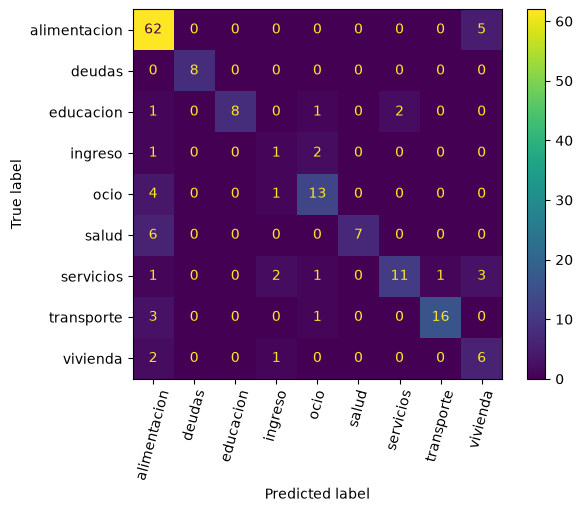

In [276]:
from sklearn.metrics import ConfusionMatrixDisplay, classification_report


modelo_categoria_svm = entrenar_modelo(svm,SMOTE())
modelo_categoria_svm.fit(X_categoria_train, y_categoria_train)

y_pred = modelo_categoria_svm.predict(X_categoria_test)
print(classification_report(y_categoria_test,y_pred))
ConfusionMatrixDisplay.from_predictions(y_categoria_test,y_pred,xticks_rotation=75);

               precision    recall  f1-score   support

fijo_no_vital       0.57      1.00      0.73         4
   fijo_vital       0.69      0.84      0.76        32
     variable       0.97      0.90      0.93       134

     accuracy                           0.89       170
    macro avg       0.74      0.91      0.81       170
 weighted avg       0.91      0.89      0.89       170



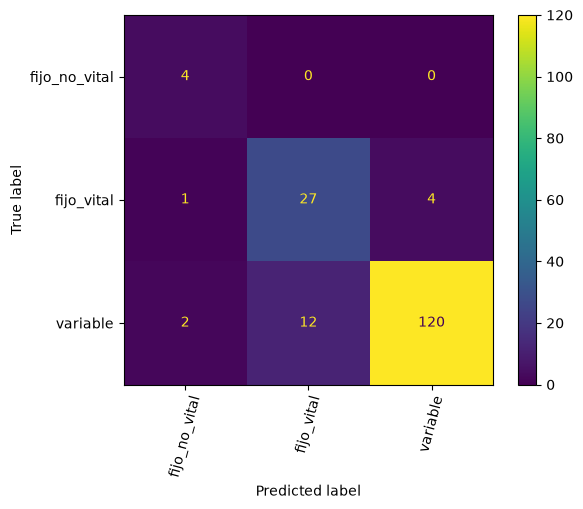

In [277]:
modelo_cualidad_svm = entrenar_modelo(svm,SMOTE())
modelo_cualidad_svm.fit(X_cualidad_train,y_cualidad_train)

y_pred = modelo_cualidad_svm.predict(X_cualidad_test)
print(classification_report(y_cualidad_test,y_pred))
ConfusionMatrixDisplay.from_predictions(y_cualidad_test,y_pred,xticks_rotation=75);

In [280]:
# modelo_cualidad_svm = entrenar_modelo(svm,SMOTE())
# modelo_cualidad_svm.fit(X_cualidad_train,y_cualidad_train)

# y_pred = modelo_categoria_svm.predict(X_cualidad_test)
# print(classification_report(y_categoria_test,y_pred))
# ConfusionMatrixDisplay.from_predictions(y_categoria_test,y_pred,xticks_rotation=75);